In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from scipy.stats import probplot, genpareto
from statsmodels.graphics.tsaplots import plot_acf


### Download data

In [2]:
ticker = "NVDA"

data = yf.download(tickers = ticker, start = '2005-01-01', progress = True)

data.head

# CALCULATE DAILY RETURNS AND LOG RETURNS
data['pct_returns'] = data['Close'].pct_change()


[*********************100%***********************]  1 of 1 completed


### Plot returns

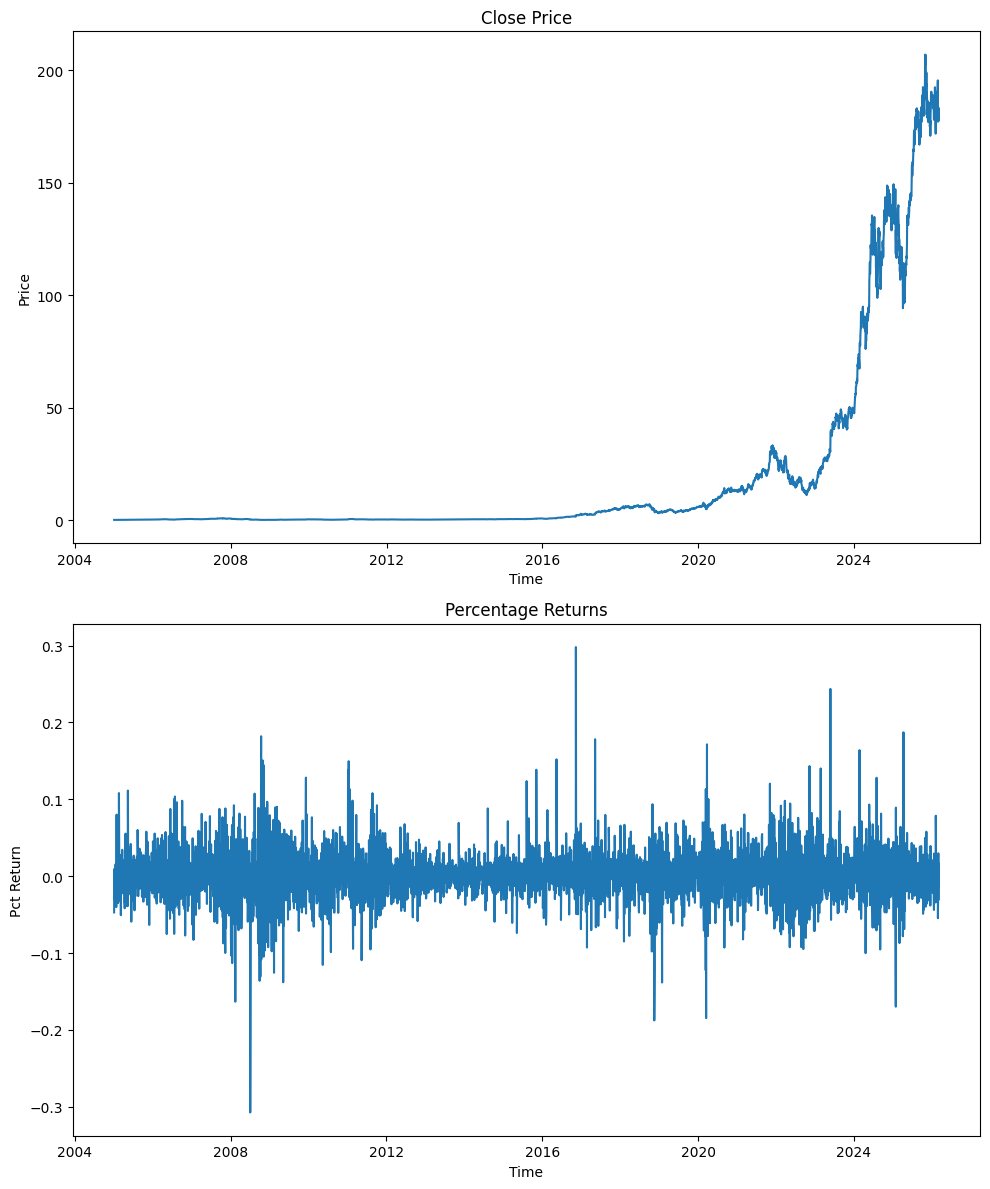

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Close Price
axes[0].plot(data['Close'])
axes[0].set_title("Close Price")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price")

# Percentage Returns
axes[1].plot(data['pct_returns'])
axes[1].set_title("Percentage Returns")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Pct Return")

plt.tight_layout()

plt.show()

### Dickey Fuller test
Statistical test for stationarity

In [4]:

y = data['pct_returns']
def ADF_test(timeseries, dataDesc):
    print(' > Is the {} stationary ?'.format(dataDesc))
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    print('Test statistic = {:.3f}'.format(dftest[0]))
    print('P-value = {:.3f}'.format(dftest[1]))
    print('Critical values :')
    for k, v in dftest[4].items():
        print('\t{}: {} - The data is {} stationary with {}% confidence'.format(k, v, 'not' if v<dftest[0] else '', 100-int(k[:-1])))

ADF_test(y,'raw data')

 > Is the raw data stationary ?
Test statistic = -14.895
P-value = 0.000
Critical values :
	1%: -3.4315832642803406 - The data is  stationary with 99% confidence
	5%: -2.8620849763501828 - The data is  stationary with 95% confidence
	10%: -2.5670600903865166 - The data is  stationary with 90% confidence


### ACF

The autocorrelation function (ACF) plot is used to visually check for independence in returns or absolute returns:

- For raw returns $r_t$, ACF shows correlation at lag $k$:

$$
\rho_k = \frac{\mathrm{Cov}(r_t, r_{t-k})}{\mathrm{Var}(r_t)}
= \frac{\mathbb{E}[(r_t - \mu)(r_{t-k}-\mu)]}{\sigma^2}
$$

- For absolute returns $|r_t|$, ACF highlights **volatility clustering**, since even if returns are uncorrelated, $|r_t|$ often exhibits persistence.

**Interpretation:**

- $\rho_k \approx 0$ for all $k>0$ → returns are consistent with IID.
- Significant $\rho_k$ in $|r_t|$ is evidence of **conditional heteroskedasticity** (volatility clustering).

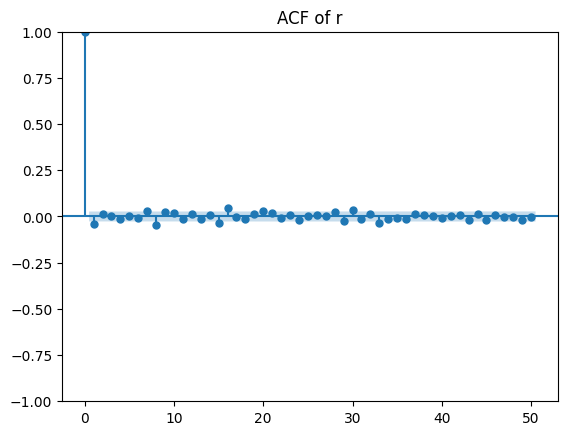

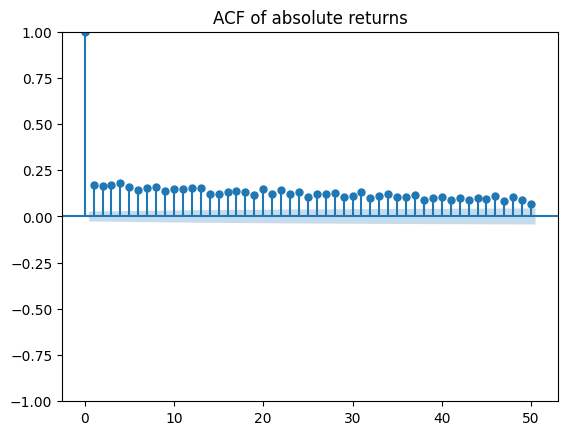

In [7]:

r = data["pct_returns"].dropna()
r_abs = np.abs(data["pct_returns"].dropna())

plot_acf(r, lags=50)
plt.title("ACF of r")
plt.show()

plot_acf(r_abs, lags=50)
plt.title("ACF of absolute returns")
plt.show()


### GARCH for Volatility

GARCH estimates volatility by modeling the conditional variance of returns as a function of past squared returns and past variances:

$
\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2
$

Hence, large past shocks $r_{t-1}^2$ and previously high volatility $\sigma_{t-1}^2$ increase the current volatility estimate.

$\omega$ is a constant term that represents the baseline (long-run) level of variance.

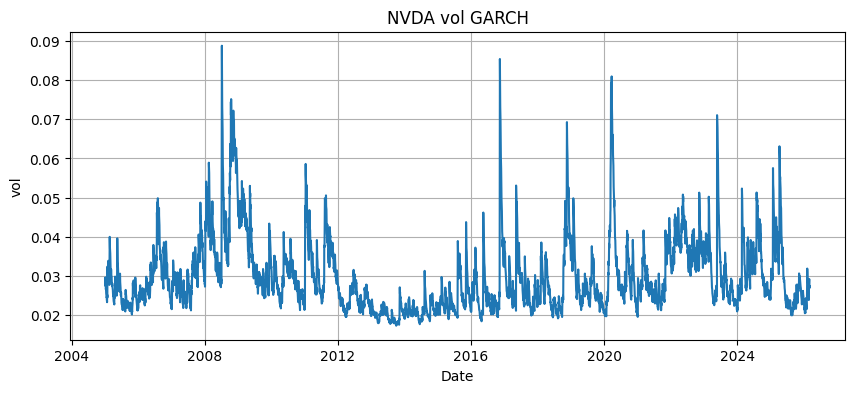

In [10]:

r_copy = data["pct_returns"].dropna() * 100  # scaling helps numerics

model = arch_model(r_copy, vol="GARCH", p=1, q=1, mean="Zero")
res = model.fit(disp="off")

# print(res.summary())

sigma = res.conditional_volatility / 100
# print(sigma)

plt.figure(figsize = (10, 4))
plt.plot(sigma)
plt.title(f"{ticker} vol GARCH")
plt.xlabel("Date")
plt.ylabel("vol")
plt.grid(True)
plt.show()



In [11]:
# MAKING LOSSES THE RIGHT TAIL

pct_returns = data['pct_returns'].dropna()  # remove NaNs

L = (-pct_returns/sigma)


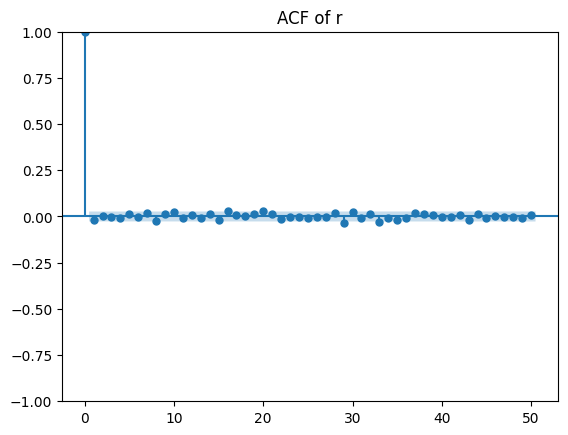

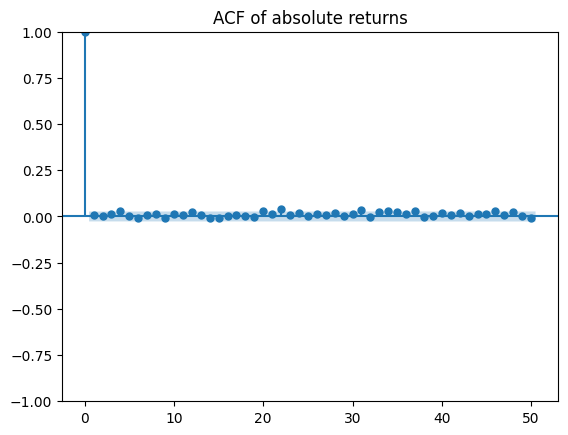

In [ ]:
# TRY ACF AGAIN

plot_acf(L, lags=50)
plt.title("ACF of r")
plt.show()

plot_acf(np.abs(L), lags=50)
plt.title("ACF of absolute returns")
plt.show()

### Mean Residual Life Plot

The mean residual life (MRL) plot helps choose a threshold for extreme value analysis by plotting the average excess above a threshold against the threshold value:


$$
\left(u,\; \frac{1}{n_u}\sum_{i: \; x_i > u} (x_i - u)\right),
$$

where $n_u = \#\{i : x_i > u\}$ is the number of observations exceeding the threshold $u$.

If the plot is approximately linear above some threshold $u$, it suggests that exceedances over $u$ can be modeled using a Generalized Pareto Distribution (because of the linearity of the mean).

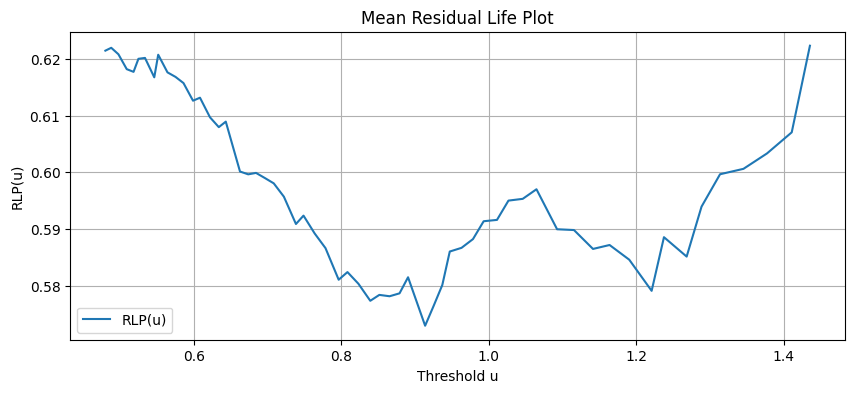

In [17]:

def MRL(u, z):
    
    filtered_z = z[z > u]
    
    if len(filtered_z) == 0:
        return 0.0 
        
    sum_terms = (filtered_z - u)
    return 1 / len(filtered_z) * np.sum(sum_terms)


u_values = np.quantile(L, np.linspace(0.75, 0.95, num=60))

result_array = np.array([[u, MRL(u, L)] for u in u_values])


# Plot the results

plt.figure(figsize = (10, 4))
plt.plot(result_array[:, 0], result_array[:, 1], label='RLP(u)')
plt.xlabel('Threshold u')
plt.ylabel('RLP(u)')
plt.title('Mean Residual Life Plot')
plt.grid(True)
plt.legend()
plt.show()


### Andersson-Darling

The Anderson–Darling test (right-tail version used here) evaluates the goodness-of-fit of a model by placing extra weight on discrepancies in the upper tail of the distribution:

$$
A^2 = -n - \frac{1}{n}\sum_{i=1}^{n} (2i-1)\left[\log F(x_{(i)}) + \log\!\left(1 - F(x_{(n+1-i)})\right)\right],
$$

It is originally derived from:

$$
A^2 = n \int_{-\infty}^{\infty}
\frac{\left(F_n(x) - F(x)\right)^2}{F(x)\,(1 - F(x))} \, dF(x),
$$

where $F_n(x)$ is the empirical distribution function and $F(x)$ is the fitted CDF. The weight function $\frac{1}{F(x)(1-F(x))}$ gives much larger weight to the tails, when $F(x)\to1$.

The right–tail Anderson–Darling statistic emphasizes deviations in the upper tail by weighting discrepancies more heavily as $F(x) \to 1$:

$$
A_R^2
=
n \int_{-\infty}^{\infty}
\frac{\left(F_n(x)-F(x)\right)^2}{1-F(x)} \, dF(x)
$$


--- Optimization Complete ---
Optimal Threshold (u): 1.2105
Number of Tail Events: 419
Minimum AD_R Score:    0.0925


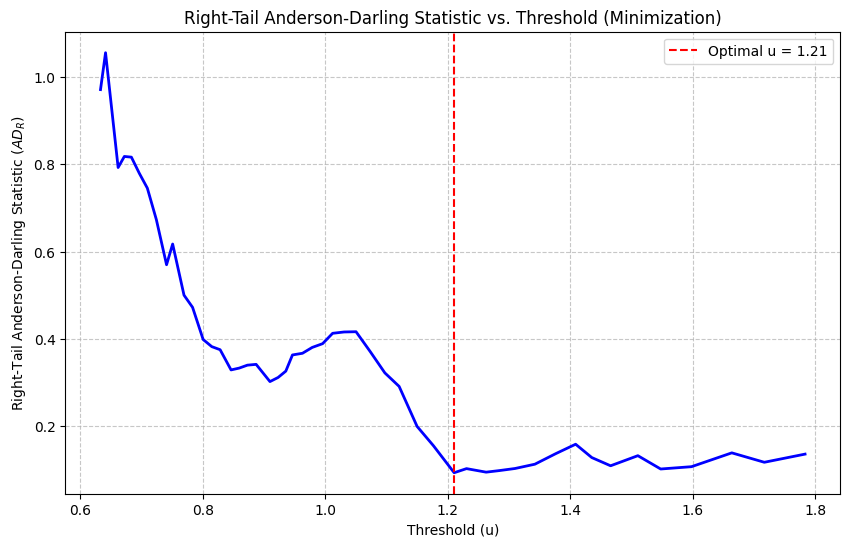

In [22]:

# (We stop at 96% to ensure we don't drop below ~200 data points)
percentiles = np.linspace(80, 97.5, 50)
thresholds = np.percentile(L, percentiles)

ad_scores = []
valid_thresholds = []
n_exceedances = []

# --- 3. The Right-Tail Anderson-Darling Loop ---
for u in thresholds:
    # Get exceedances
    exceedances = L[L > u] - u
    n = len(exceedances)
    
    # Safety check: require at least 50 points for a stable GPD fit
    if n < 50:
        continue
        
    # Fit the GPD
    shape, loc, scale = genpareto.fit(exceedances, floc=0)
    
    # Sort the data (required for the AD formula)
    x_sorted = np.sort(exceedances)
    
    # Calculate the theoretical CDF values for our data points
    # We clip the upper bound slightly below 1 to prevent log(0) errors in the math
    cdf_vals = genpareto.cdf(x_sorted, c=shape, loc=0, scale=scale)
    cdf_vals = np.clip(cdf_vals, 1e-10, 1 - 1e-10) 
    
    # Calculate the Right-Tail Anderson-Darling Statistic (AD_R) ( OBS !!! )
    i = np.arange(1, n + 1)
    
    term1 = n / 2.0
    term2 = -2.0 * np.sum(cdf_vals)
    term3 = -np.sum((2.0 - (2.0 * i - 1.0) / n) * np.log(1.0 - cdf_vals))
    
    ad_stat = term1 + term2 + term3
    
    ad_scores.append(ad_stat)
    valid_thresholds.append(u)
    n_exceedances.append(n)

# Find the Optimal Threshold 
# The best threshold is the one that minimizes the AD_R statistic
best_idx = np.argmin(ad_scores)
optimal_u = valid_thresholds[best_idx]
optimal_n = n_exceedances[best_idx]
min_ad = ad_scores[best_idx]

print(f"--- Optimization Complete ---")
print(f"Optimal Threshold (u): {optimal_u:.4f}")
print(f"Number of Tail Events: {optimal_n}")
print(f"Minimum AD_R Score:    {min_ad:.4f}")

# Plot the curve
plt.figure(figsize=(10, 6))
plt.plot(valid_thresholds, ad_scores, color='blue', linewidth=2)
plt.axvline(optimal_u, color='red', linestyle='--', label=f'Optimal u = {optimal_u:.2f}')
plt.title('Right-Tail Anderson-Darling Statistic vs. Threshold (Minimization)')
plt.xlabel('Threshold (u)')
plt.ylabel('Right-Tail Anderson-Darling Statistic ($AD_R$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Fitting the GPD 

In [23]:
chosen_u = 1.21 

u = 1.21  
data = L[L > u] - u
data = data[np.isfinite(data)]

n = len(data)
if n < 50:
    print(f"Warning: only {n} exceedances above optimal_u={u:.4f}. Fits/plots may be unstable.")

shape, loc, scale = genpareto.fit(data, floc=0)

print(f"Optimal threshold u:   {u:.4f}")
print(f"Exceedances N:         {n}")
print(f"Fitted Shape (xi):     {shape:.4f}")
print(f"Fitted Scale (sigma):  {scale:.4f}")

Optimal threshold u:   1.2100
Exceedances N:         420
Fitted Shape (xi):     0.1822
Fitted Scale (sigma):  0.4709


### Plots to asses fit

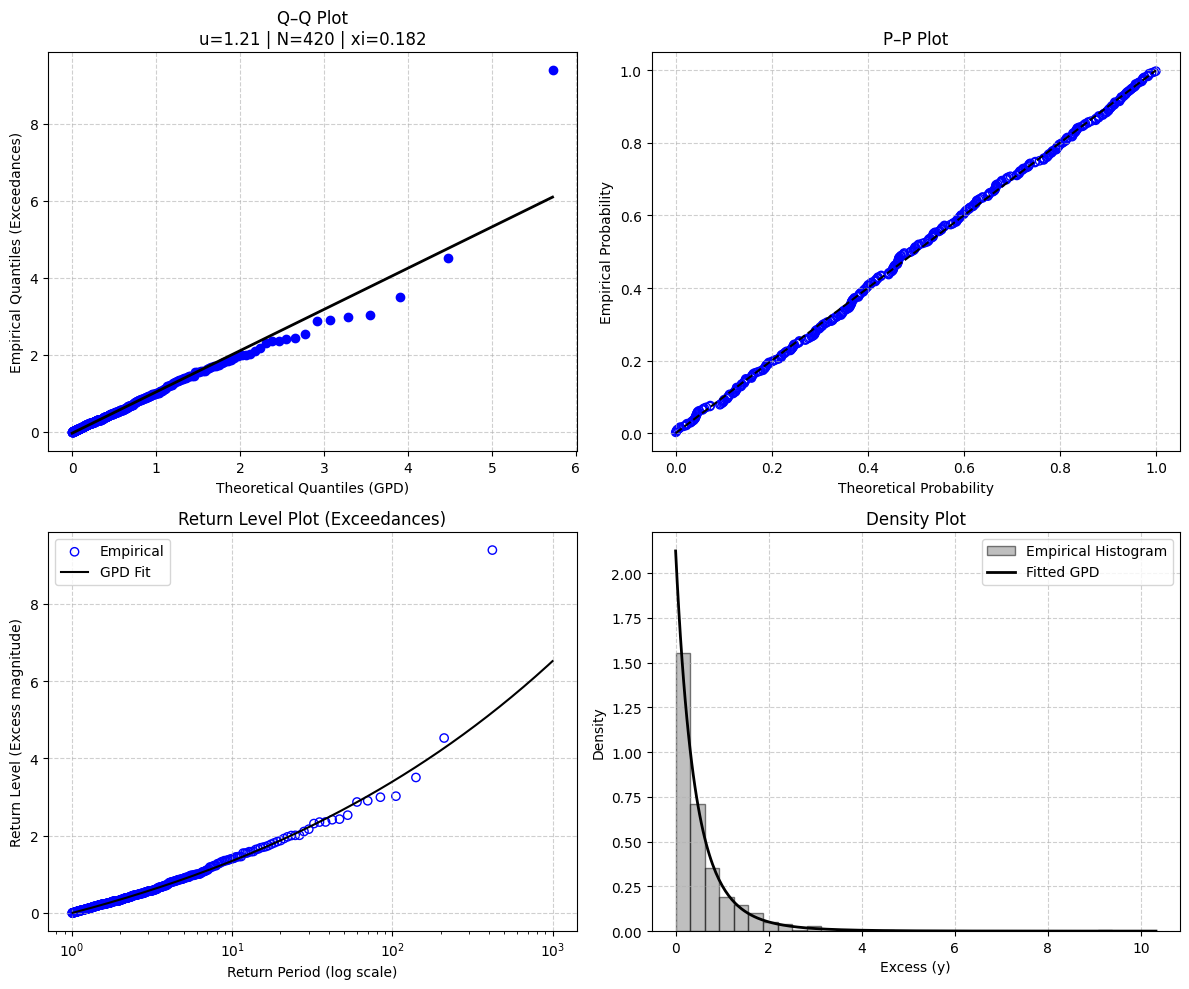

In [34]:
# sort and prepare data

sorted_data = np.sort(data)
empirical_p = np.arange(1, n + 1) / (n + 1)

# Create Dashboard

fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# Q–Q plot 
ax = axes[0,0]
probplot(data, dist=genpareto, sparams=(shape, 0, scale), plot=ax)

lines = ax.get_lines()
if len(lines) >= 2:
    lines[1].set_color("black")
    lines[1].set_linewidth(2)

ax.set_title(f"Q–Q Plot\nu={u:.2f} | N={n} | xi={shape:.3f}")
ax.set_xlabel("Theoretical Quantiles (GPD)")
ax.set_ylabel("Empirical Quantiles (Exceedances)")
ax.grid(True, linestyle="--", alpha=0.6)


# P–P plot
ax = axes[0,1]
theoretical_p = genpareto.cdf(sorted_data, c=shape, loc=0, scale=scale)
theoretical_p = np.clip(theoretical_p, 1e-12, 1 - 1e-12)

ax.scatter(theoretical_p, empirical_p, facecolors='none', edgecolors='b')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_title("P–P Plot")
ax.set_xlabel("Theoretical Probability")
ax.set_ylabel("Empirical Probability")
ax.grid(True, linestyle="--", alpha=0.6)


# Return level plot
ax = axes[1,0]
empirical_return_periods = 1 / (1 - empirical_p)

m_range = np.logspace(np.log10(1.01), np.log10(1000), 200)
theoretical_return_levels = genpareto.ppf(1 - 1/m_range, c=shape, loc=0, scale=scale)

ax.scatter(empirical_return_periods, sorted_data, facecolors='none', edgecolors='b', label='Empirical')
ax.plot(m_range, theoretical_return_levels, 'k-', label='GPD Fit')
ax.set_xscale('log')
ax.set_title("Return Level Plot (Exceedances)")
ax.set_xlabel("Return Period (log scale)")
ax.set_ylabel("Return Level (Excess magnitude)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()


# Density plot 
ax = axes[1,1]
ax.hist(data, bins=30, density=True, alpha=0.5, color='gray', edgecolor='black', label='Empirical Histogram')

x_range = np.linspace(0, max(data) * 1.1 if len(data) else 1, 300)
theoretical_pdf = genpareto.pdf(x_range, c=shape, loc=0, scale=scale)
ax.plot(x_range, theoretical_pdf, 'black', lw=2, label='Fitted GPD')

ax.set_title("Density Plot")
ax.set_xlabel("Excess (y)")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig("gpd_diagnostics_optimal_u.png", dpi=200)
plt.show()